In [5]:
import pandas as pd
import os

# Download the Titanic dataset if the cleaned version doesn't exist
if not os.path.exists('Titanic_Cleaned.csv'):
    url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
    df_raw = pd.read_csv(url)

    # Basic cleaning to match your expected 'Titanic_Cleaned.csv' structure
    df_raw['Age'] = df_raw['Age'].fillna(df_raw['Age'].median())
    df_raw['Embarked'] = df_raw['Embarked'].fillna('S')
    df_raw['Fare'] = df_raw['Fare'].fillna(df_raw['Fare'].median())
    df_raw['FamilySize'] = df_raw['Parch'] + df_raw['SibSp'] + 1
    df_raw['IsAlone'] = (df_raw['FamilySize'] == 1).astype(int)

    # Creating a dummy AgeGroup for your LabelEncoder
    bins = [0, 12, 20, 40, 60, 80]
    labels = ['Child', 'Teen', 'Adult', 'MiddleAge', 'Senior']
    df_raw['AgeGroup'] = pd.cut(df_raw['Age'], bins=bins, labels=labels)

    df_raw.to_csv('Titanic_Cleaned.csv', index=False)
    print('✅ Titanic_Cleaned.csv created!')

✅ Titanic_Cleaned.csv created!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, auc)
import warnings
warnings.filterwarnings('ignore')

print('✅ Libraries imported!')

✅ Libraries imported!


In [6]:
df = pd.read_csv('Titanic_Cleaned.csv')

# Encode categorical columns
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])         # male=1, female=0
df['Embarked'] = le.fit_transform(df['Embarked'])
df['AgeGroup'] = le.fit_transform(df['AgeGroup'].astype(str))

# Select features
features = ['Pclass','Sex','Age','Fare','FamilySize','IsAlone','Embarked']
X = df[features]
y = df['Survived']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f'✅ Train size: {X_train.shape}, Test size: {X_test.shape}')

✅ Train size: (712, 7), Test size: (179, 7)


In [7]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = {'model': model, 'pred': y_pred, 'accuracy': acc}
    print(f'✅ {name}: Accuracy = {acc*100:.2f}%')

✅ Logistic Regression: Accuracy = 79.89%
✅ Decision Tree: Accuracy = 77.65%
✅ Random Forest: Accuracy = 82.12%


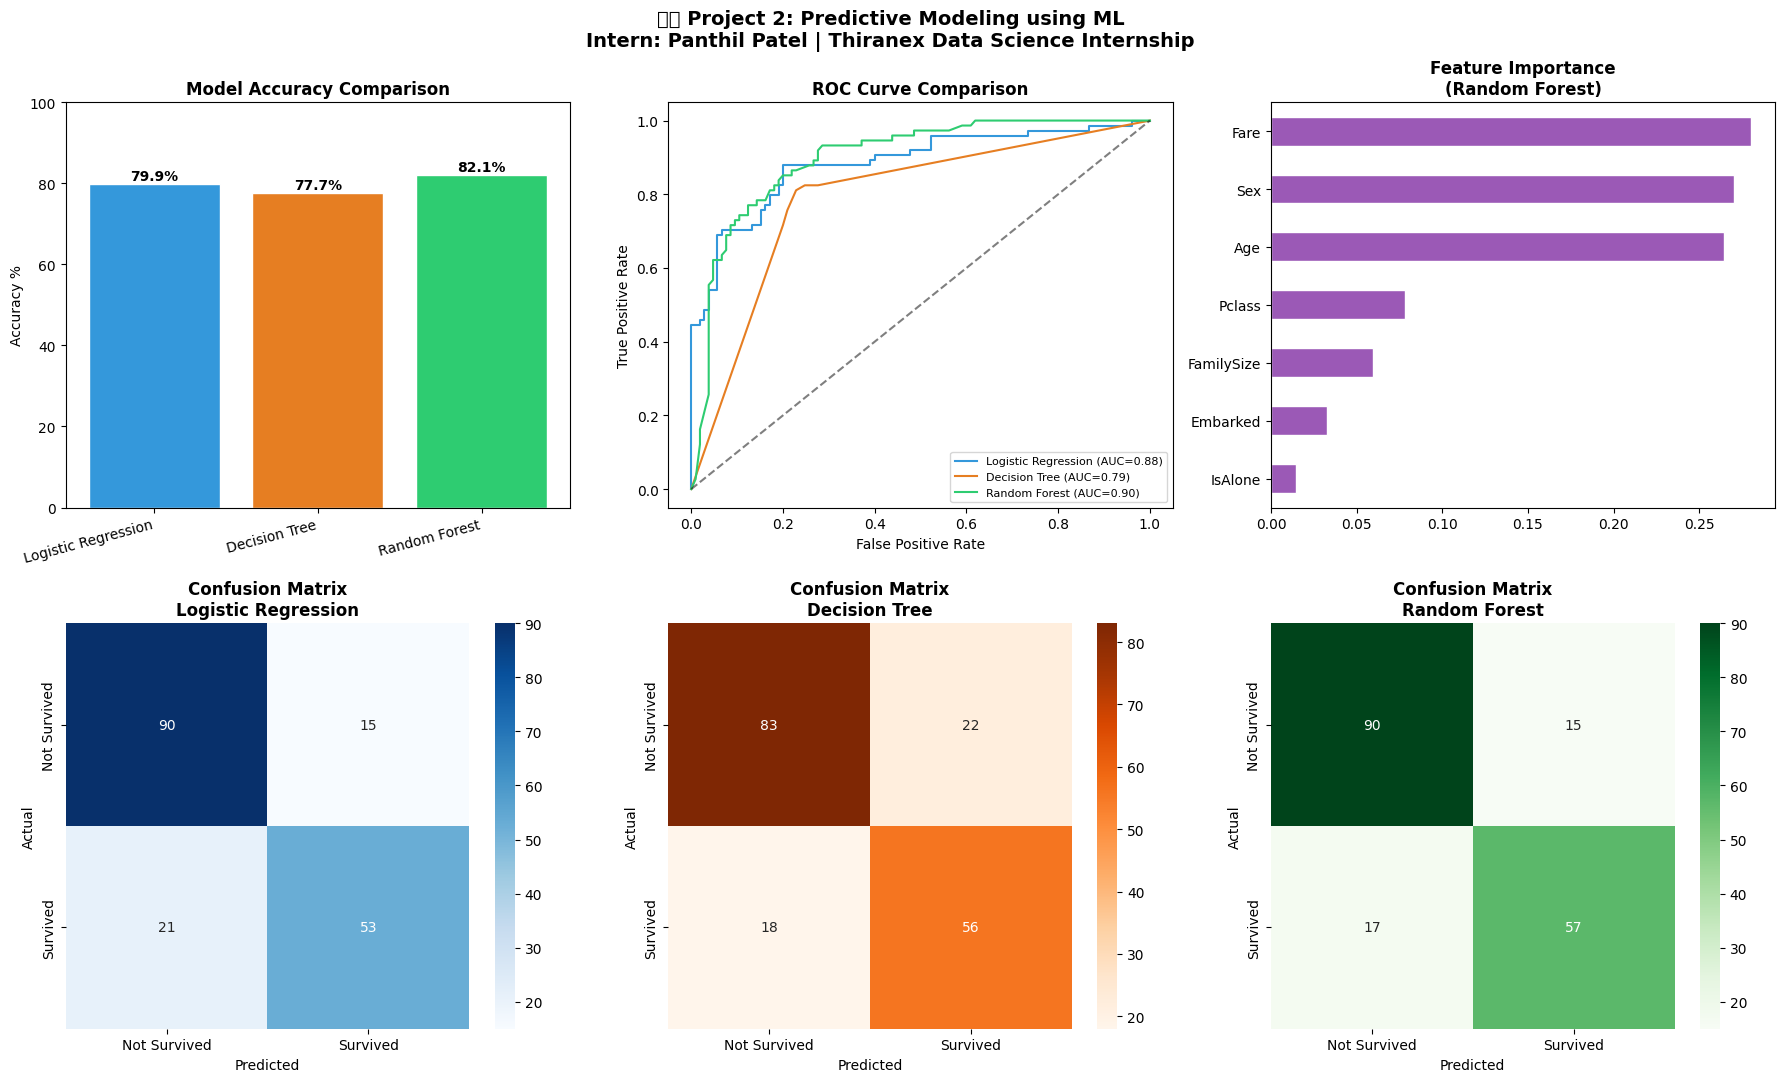

✅ Dashboard saved!


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('ထဠ Project 2: Predictive Modeling using ML\nIntern: Panthil Patel | Thiranex Data Science Internship',
             fontsize=14, fontweight='bold')

# 1. Model Accuracy Comparison
ax = axes[0, 0]
names = list(results.keys())
accs = [results[n]['accuracy']*100 for n in names]
bars = ax.bar(names, accs, color=['#3498db','#e67e22','#2ecc71'], edgecolor='white')
ax.set_title('Model Accuracy Comparison', fontweight='bold')
ax.set_ylabel('Accuracy %')
ax.set_ylim(0, 100)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f'{acc:.1f}%', ha='center', fontweight='bold')
ax.set_xticklabels(names, rotation=15, ha='right')

# 2,3,4. Confusion Matrices
colors = ['Blues', 'Oranges', 'Greens']
for idx, (name, color) in enumerate(zip(names, colors)):
    curr_ax = axes[1, idx]
    cm = confusion_matrix(y_test, results[name]['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=color, ax=curr_ax,
                xticklabels=['Not Survived','Survived'],
                yticklabels=['Not Survived','Survived'])
    curr_ax.set_title(f'Confusion Matrix\n{name}', fontweight='bold')
    curr_ax.set_xlabel('Predicted')
    curr_ax.set_ylabel('Actual')

# ROC Curve
ax_roc = axes[0, 1]
for name, color in zip(names, ['#3498db','#e67e22','#2ecc71']):
    y_prob = results[name]['model'].predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, label=f'{name} (AUC={roc_auc:.2f})')
ax_roc.plot([0,1],[0,1],'k--', alpha=0.5)
ax_roc.set_title('ROC Curve Comparison', fontweight='bold')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.legend(fontsize=8)

# Feature Importance (Random Forest)
ax_fi = axes[0, 2]
rf = results['Random Forest']['model']
importances = pd.Series(rf.feature_importances_, index=features).sort_values()
importances.plot(kind='barh', ax=ax_fi, color='#9b59b6', edgecolor='white')
ax_fi.set_title('Feature Importance\n(Random Forest)', fontweight='bold')

plt.tight_layout()
plt.savefig('Project2_ML_Dashboard.png', bbox_inches='tight', dpi=150)
plt.show()
print('✅ Dashboard saved!')

In [9]:
# Best model report
print('ထထ Random Forest - Classification Report:')
print(classification_report(y_test, results['Random Forest']['pred'],
      target_names=['Not Survived', 'Survived']))

# Download (Skipping git push as repo credentials aren't set)
from google.colab import files
if os.path.exists('Project2_ML_Dashboard.png'):
    files.download('Project2_ML_Dashboard.png')
    print('✅ Dashboard ready for download!')

ထထ Random Forest - Classification Report:
              precision    recall  f1-score   support

Not Survived       0.84      0.86      0.85       105
    Survived       0.79      0.77      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Dashboard ready for download!
